In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_image(path="image.png"):
    img = cv2.imread(path)
    if img is None:
        print(f"'{path}' not found — using a synthetic placeholder image instead.")
        img = np.full((400, 400, 3), (245, 245, 245), dtype=np.uint8)
        cv2.rectangle(img, (40, 40), (360, 360), (180, 120, 40), 3)
        cv2.rectangle(img, (100, 100), (300, 300), (40, 140, 200), -1)
        cv2.putText(img, "CV LAB 03", (70, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (20, 20, 20), 2)
        cv2.circle(img, (200, 200), 60, (255, 255, 255), 4)
    return img

def show(before, after, title_before="Before", title_after="After", figsize=(12, 5)):
    b = cv2.cvtColor(before, cv2.COLOR_BGR2RGB)
    a = cv2.cvtColor(after, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.subplot(1, 2, 1); plt.imshow(b); plt.title(title_before); plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(a); plt.title(title_after); plt.axis("off")
    plt.tight_layout(); plt.show()

image = load_image("image.png")
height, width = image.shape[:2]
print("Image size (H x W):", height, "x", width)


'image.png' not found — using a synthetic placeholder image instead.
Image size (H x W): 400 x 400


#TASK1

Linear scaling matrix S:
 [[3. 0.]
 [0. 3.]]

Full centered affine matrix M:
 [[   3.    0. -400.]
 [   0.    3. -400.]]


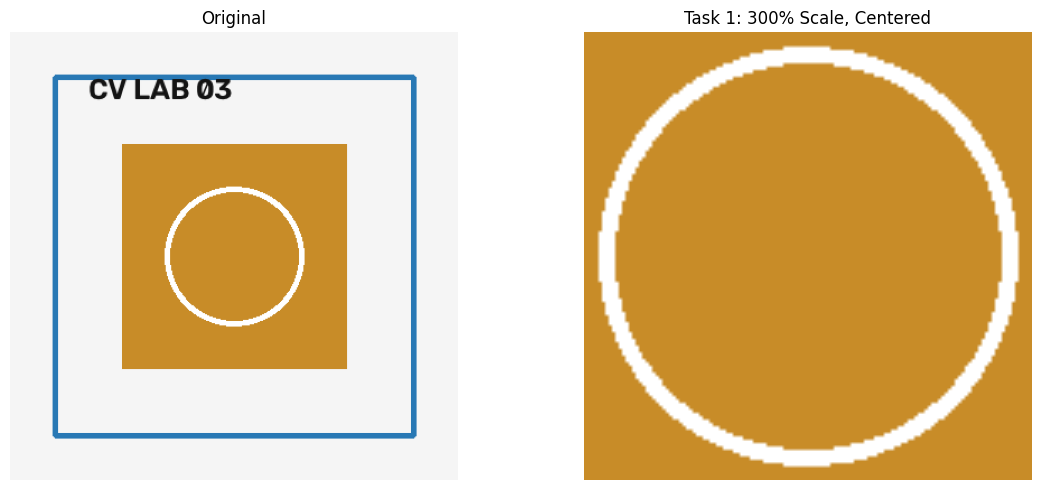

In [4]:
# Task 1: The Tiny Fingerprint (Linear - Scale)
sx, sy = 3.0, 3.0  # 300% enlargement on x and y

# Manually built 2x2 scaling matrix (Section 5.3: diagonal = independent axis scaling)
S = np.array([
    [sx, 0.0],
    [0.0, sy]
])

# Linear transforms are anchored at the origin -> compute a translation
# that re-centers the enlarged fingerprint on screen
cx, cy = width / 2, height / 2
shift_x = cx - sx * cx
shift_y = cy - sy * cy

# Fold into the 2x3 matrix warpAffine expects: [S | shift]
M_task1 = np.float32([
    [S[0, 0], S[0, 1], shift_x],
    [S[1, 0], S[1, 1], shift_y]
])

task1_result = cv2.warpAffine(image, M_task1, (width, height))

print("Linear scaling matrix S:\n", S)
print("\nFull centered affine matrix M:\n", M_task1)
show(image, task1_result, "Original", "Task 1: 300% Scale, Centered")


#TASK2

Rotation matrix R (theta = -45 deg):
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

New canvas size (W x H): 565 x 565


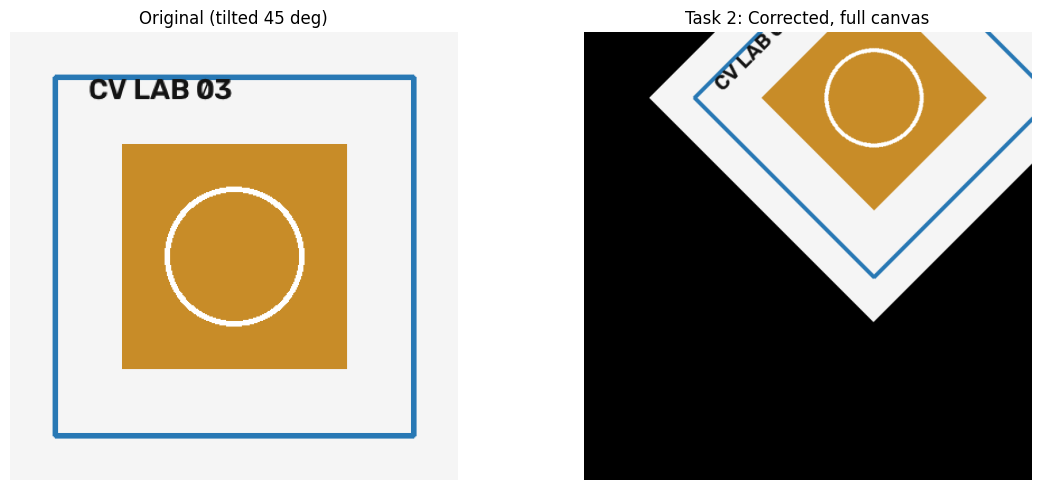

In [5]:
# Task 2: The Dizzy Satellite (Linear - Rotation)
tilt = 45                 # the accidental tilt reported by the satellite
theta = np.deg2rad(-tilt) # rotate by the OPPOSITE angle to correct it

# Manually built 2x2 rotation matrix
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

# Manually compute the new bounding box so the rotated corners aren't chopped off
abs_cos, abs_sin = abs(R[0, 0]), abs(R[1, 0])
new_w = int(height * abs_sin + width * abs_cos)
new_h = int(height * abs_cos + width * abs_sin)

cx, cy = width / 2, height / 2
M_task2 = np.float32([
    [R[0, 0], R[0, 1], 0],
    [R[1, 0], R[1, 1], 0]
])
# re-center the rotated image in the enlarged canvas
M_task2[0, 2] += (new_w / 2) - cx
M_task2[1, 2] += (new_h / 2) - cy

task2_result = cv2.warpAffine(image, M_task2, (new_w, new_h))

print("Rotation matrix R (theta = -45 deg):\n", R)
print("\nNew canvas size (W x H):", new_w, "x", new_h)
show(image, task2_result, "Original (tilted 45 deg)", "Task 2: Corrected, full canvas")


#TASK3

Shear matrix Sh (k = -0.5):
 [[ 1.  -0.5]
 [ 0.   1. ]]


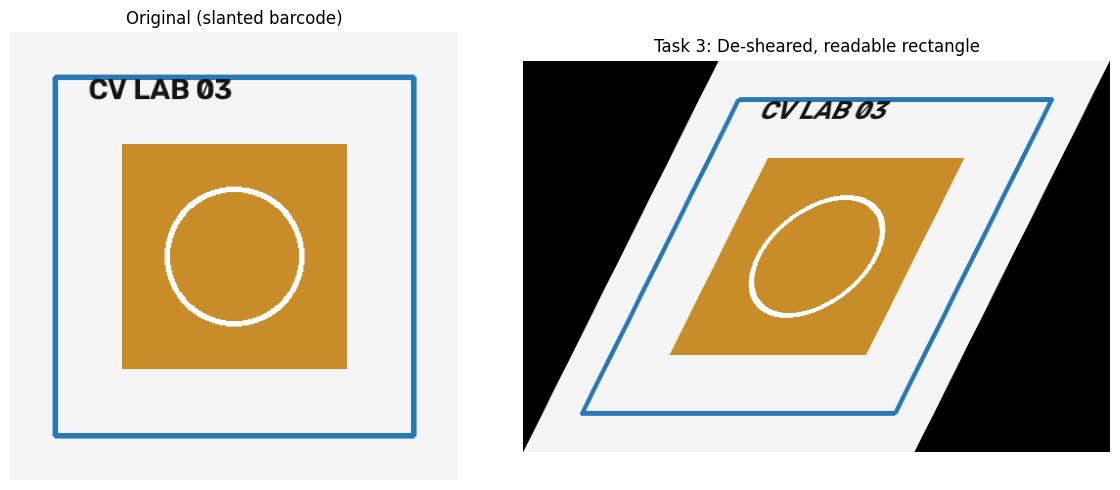

In [6]:
# Task 3: The Fast Train Barcode (Linear - Shear)
k_scan = 0.5     # the slant introduced by the fast-moving train
kx = -k_scan      # apply the inverse shear to straighten it

# Manually built 2x2 horizontal shear matrix
Sh = np.array([
    [1.0, kx],
    [0.0, 1.0]
])

new_width = int(width + abs(kx) * height)
extra_shift = abs(kx) * height if kx < 0 else 0  # keep content on-canvas

M_task3 = np.float32([
    [Sh[0, 0], Sh[0, 1], extra_shift],
    [Sh[1, 0], Sh[1, 1], 0]
])

task3_result = cv2.warpAffine(image, M_task3, (new_width, height))

print("Shear matrix Sh (k = -0.5):\n", Sh)
show(image, task3_result, "Original (slanted barcode)", "Task 3: De-sheared, readable rectangle")


#TASK4

Homogeneous translation matrix T:
 [[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]


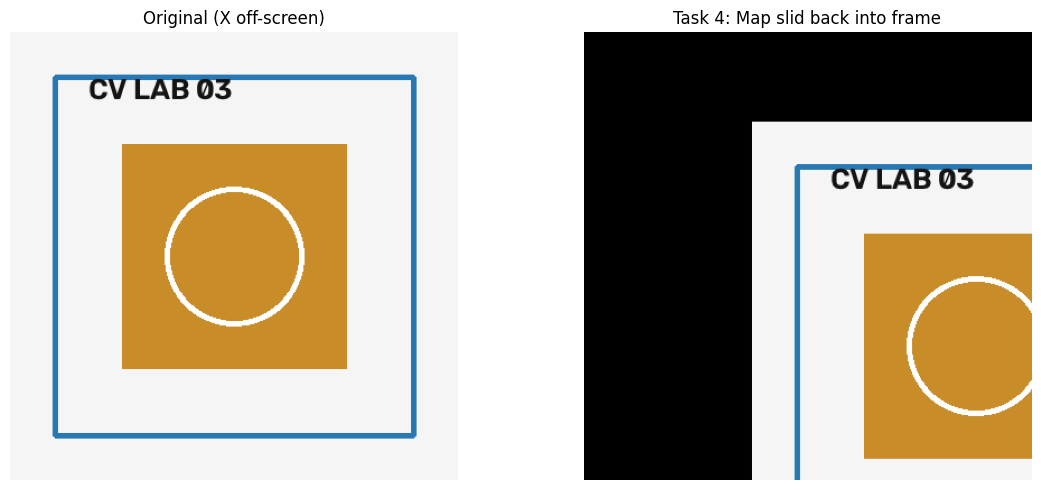

In [7]:
# Task 4: The Hidden Treasure Map (Affine - Translation)
tx, ty = 150, 80  # slide back right & down by the amount it went missing

# Full 3x3 homogeneous translation matrix (Section 6.1.1.4)
T = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
], dtype=np.float32)

# warpAffine only needs the top two rows of the homogeneous matrix
M_task4 = T[:2, :]

task4_result = cv2.warpAffine(image, M_task4, (width, height))

print("Homogeneous translation matrix T:\n", T)
show(image, task4_result, "Original (X off-screen)", "Task 4: Map slid back into frame")


#TASK5

Combined rigid matrix (T . R):
 [[  0.81915204  -0.57357644 -35.        ]
 [  0.57357644   0.81915204  20.        ]
 [  0.           0.           1.        ]]


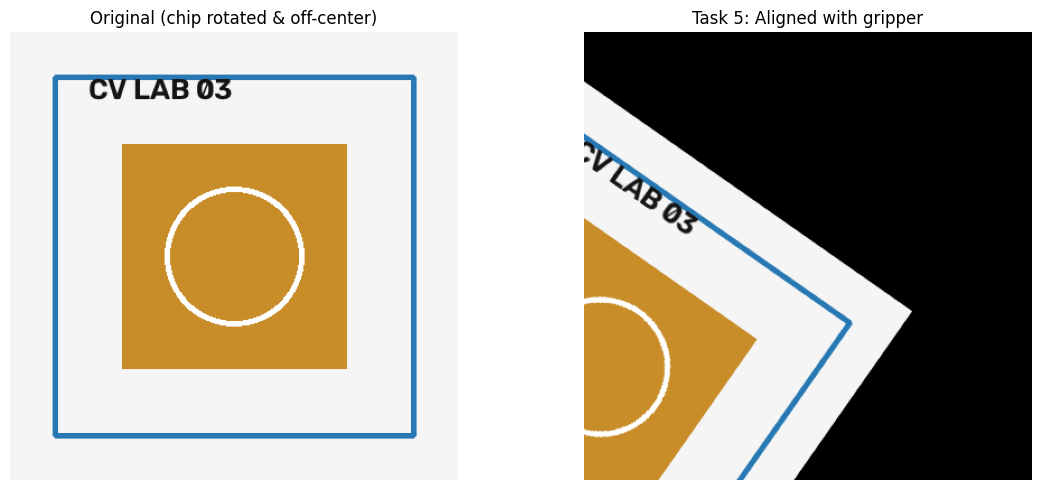

In [8]:
# Task 5: The Robot's Assembly Line (Rigid Transformation)
angle = 35                    # degrees the chip is rotated sideways
tx_chip, ty_chip = -35, 20     # offset needed to re-center under the gripper

theta = np.deg2rad(angle)
R3 = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0, 0, 1]
])
T3 = np.array([
    [1, 0, tx_chip],
    [0, 1, ty_chip],
    [0, 0, 1]
])

# Compose rotation and translation into ONE 3x3 rigid matrix
Rigid = T3 @ R3

M_task5 = Rigid[:2, :].astype(np.float32)
task5_result = cv2.warpAffine(image, M_task5, (width, height))

print("Combined rigid matrix (T . R):\n", Rigid)
show(image, task5_result, "Original (chip rotated & off-center)", "Task 5: Aligned with gripper")


#TASK6

Full 3x3 similarity matrix (scale + rotation + translation):
 [[   2.28253564   -0.74164079  -53.17897052]
 [   0.74164079    2.28253564 -369.83528512]
 [   0.            0.            1.        ]]


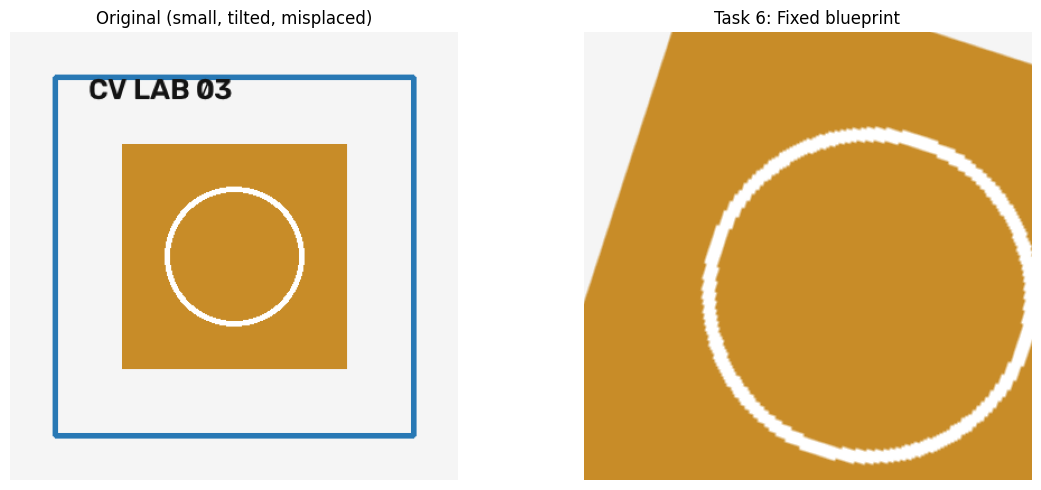

In [9]:
# Task 6: The Architect's Blueprint (Similarity Transformation)
scale = 2.4
angle = -18
tx_b, ty_b = 55, 35
center = (width // 2, height // 2)

# cv2.getRotationMatrix2D already builds rotation + uniform scale as one 2x3 matrix
M2x3 = cv2.getRotationMatrix2D(center, angle, scale)

# fold translation into the same matrix (one combined similarity operation)
M2x3[0, 2] += tx_b
M2x3[1, 2] += ty_b

# express as the full 3x3 similarity matrix for the report
Similarity = np.vstack([M2x3, [0, 0, 1]])

task6_result = cv2.warpAffine(image, M2x3, (width, height))

print("Full 3x3 similarity matrix (scale + rotation + translation):\n", Similarity)
show(image, task6_result, "Original (small, tilted, misplaced)", "Task 6: Fixed blueprint")


#TASK7

Solved general affine matrix (corruption):
 [[  0.86746988   0.23694779 -26.26506024]
 [ -0.31726908   0.96117805  71.36546185]]

Solved inverse affine matrix (fix):
 [[  1.05743741  -0.26067747  46.37702504]
 [  0.34904271   0.95434462 -58.93961708]]


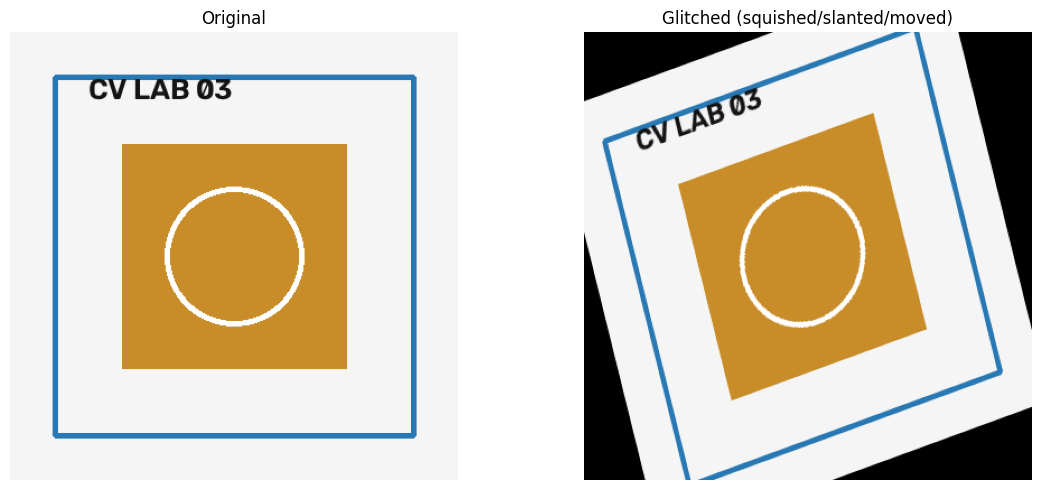

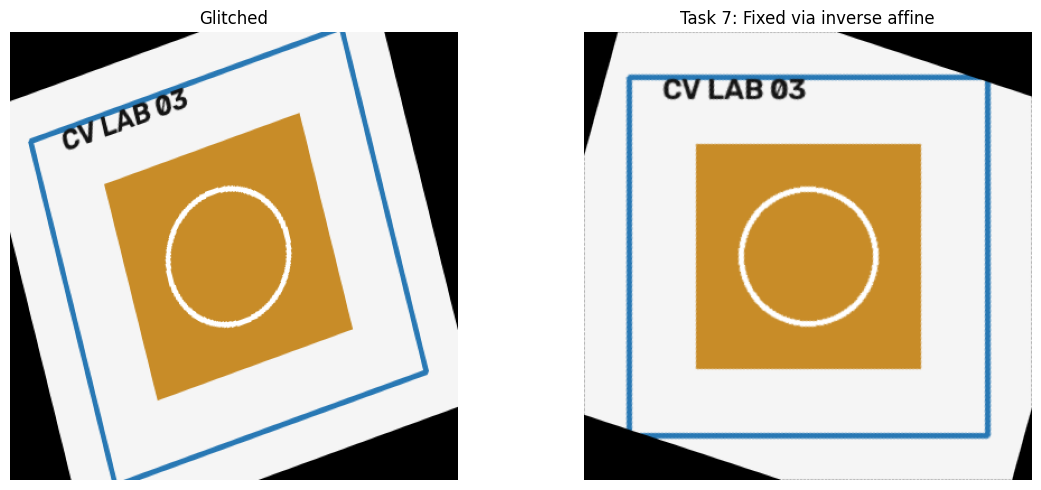

In [10]:
# Task 7: The Glitched Image (General Affine Transformation)
# 3 landmark correspondences: original position -> corrupted position
src_pts = np.float32([
    [60, 60],
    [width - 60, 90],
    [90, height - 70]
])
dst_pts = np.float32([   # where the corruption sent them (squished/slanted/moved)
    [40, 110],
    [width - 110, 50],
    [130, height - 40]
])

# Simulate the corruption (original -> glitched)
M_glitch = cv2.getAffineTransform(src_pts, dst_pts)
glitched = cv2.warpAffine(image, M_glitch, (width, height))

# Fix it: solve the INVERSE mapping (glitched points -> original points)
M_fix = cv2.getAffineTransform(dst_pts, src_pts)
fixed = cv2.warpAffine(glitched, M_fix, (width, height))

print("Solved general affine matrix (corruption):\n", M_glitch)
print("\nSolved inverse affine matrix (fix):\n", M_fix)
show(image, glitched, "Original", "Glitched (squished/slanted/moved)")
show(glitched, fixed, "Glitched", "Task 7: Fixed via inverse affine")


#TASK8

Homography (perspective) matrix H:
 [[ 2.09415387e+00  4.45886711e-01 -1.86148405e+02]
 [ 2.58858630e-01  2.07726026e+00 -9.84620769e+01]
 [ 1.05377393e-03  2.01563870e-03  1.00000000e+00]]


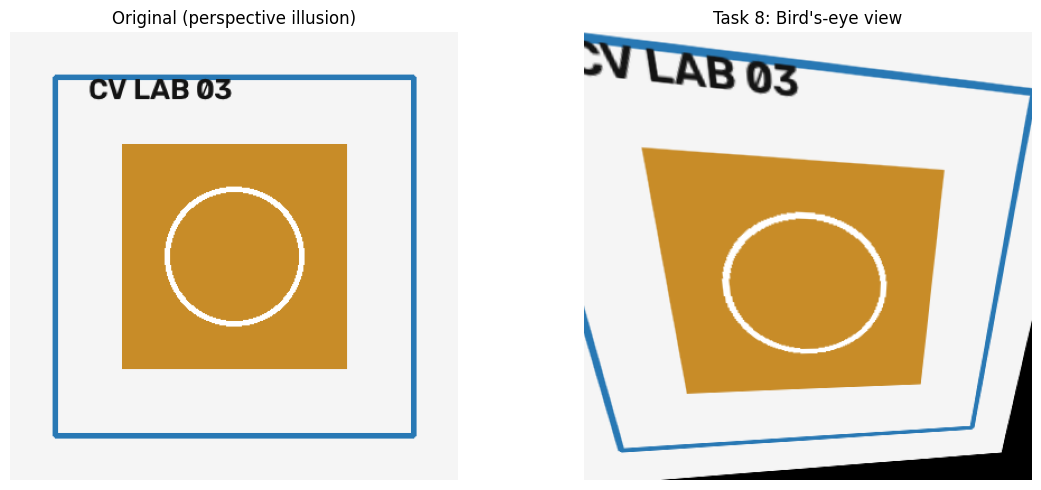

In [11]:
# Task 8: The Sidewalk Illusion (Projective - Perspective)
# 4 corners of the chalk art as they appear in the photo (a trapezoid due to perspective)
src_pts = np.float32([
    [110, 70],
    [width - 90, 50],
    [width - 50, height - 60],
    [70, height - 80]
])
# where they SHOULD be to form a perfect square (top-down / bird's-eye view)
side = min(width, height) - 120
dst_pts = np.float32([
    [60, 60],
    [60 + side, 60],
    [60 + side, 60 + side],
    [60, 60 + side]
])

# Solve the 3x3 homography H from the 4 correspondences
H_task8 = cv2.getPerspectiveTransform(src_pts, dst_pts)
task8_result = cv2.warpPerspective(image, H_task8, (width, height))

print("Homography (perspective) matrix H:\n", H_task8)
show(image, task8_result, "Original (perspective illusion)", "Task 8: Bird's-eye view")


#TASK9

Homography H (right camera -> left camera space):
 [[ 8.64981760e-01 -3.48999006e-02  4.98273531e+01]
 [ 2.30368715e-02  9.27429844e-01 -1.37118795e+01]
 [-2.54130132e-04 -5.23043761e-05  1.00000000e+00]]


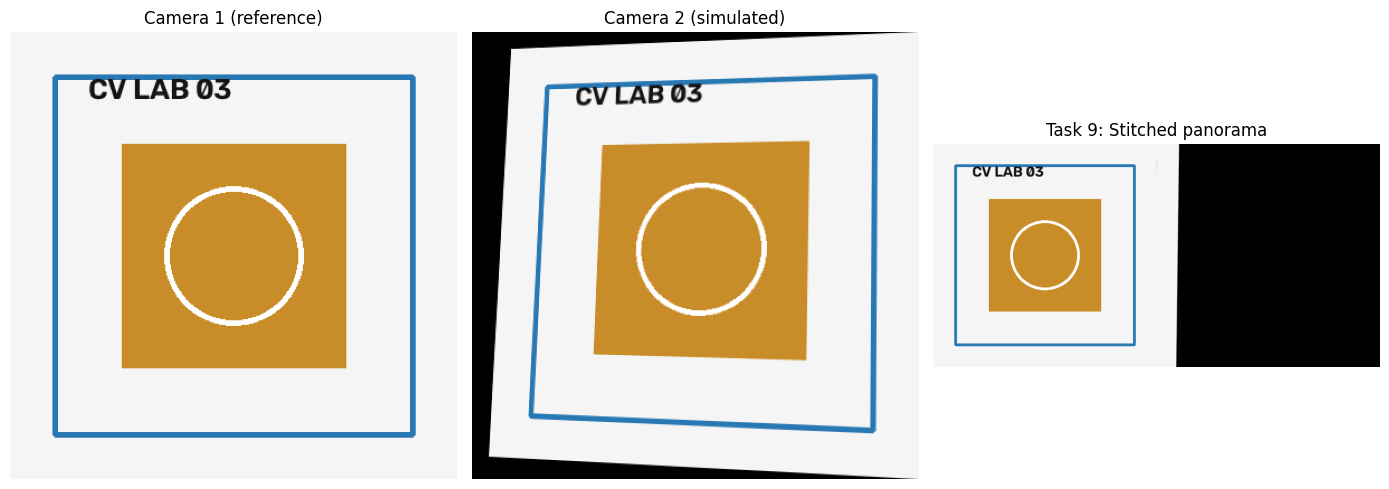

In [12]:
# Task 9: The Stadium Panorama (Projective - Homography)
left_view = image.copy()
h, w = left_view.shape[:2]

# --- Simulate a second, overlapping camera view (stand-in for a real photo) ---
pts_a = np.float32([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]])
pts_b = np.float32([[35, 15], [w - 1, 0], [w - 1, h - 1], [15, h - 1 - 20]])
M_sim = cv2.getPerspectiveTransform(pts_a, pts_b)
right_view = cv2.warpPerspective(left_view, M_sim, (w, h))

# --- 4 matching points found in BOTH images (the shared overlap region) ---
pts_left  = np.float32([[300, 100], [380, 100], [380, 300], [300, 300]])
pts_right = np.float32([[268, 108], [345, 104], [348, 296], [272, 304]])

# Homography that maps points from the RIGHT camera into the LEFT camera's space
H_pano = cv2.getPerspectiveTransform(pts_right, pts_left)

canvas_w, canvas_h = w * 2, h
stitched = cv2.warpPerspective(right_view, H_pano, (canvas_w, canvas_h))
stitched[0:h, 0:w] = left_view   # overlay the reference (left) image on top

print("Homography H (right camera -> left camera space):\n", H_pano)

plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(left_view, cv2.COLOR_BGR2RGB)); plt.title("Camera 1 (reference)"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(cv2.cvtColor(right_view, cv2.COLOR_BGR2RGB)); plt.title("Camera 2 (simulated)"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB)); plt.title("Task 9: Stitched panorama"); plt.axis("off")
plt.tight_layout(); plt.show()


#TASK10

Step 1 - Scale matrix:
 [[0.75 0.   0.  ]
 [0.   0.75 0.  ]]

Step 2 - Rigid matrix:
 [[ 9.97564050e-01  6.97564737e-02  1.43469909e+02]
 [-6.97564737e-02  9.97564050e-01  8.70026651e+01]]

Step 3 - Projective (Homography) matrix:
 [[ 1.53097544e+00  8.30576562e-02  2.00000000e+02]
 [-2.96039770e-01  1.75998161e+00  1.10000000e+02]
 [-2.27902105e-04 -2.03592547e-04  1.00000000e+00]]


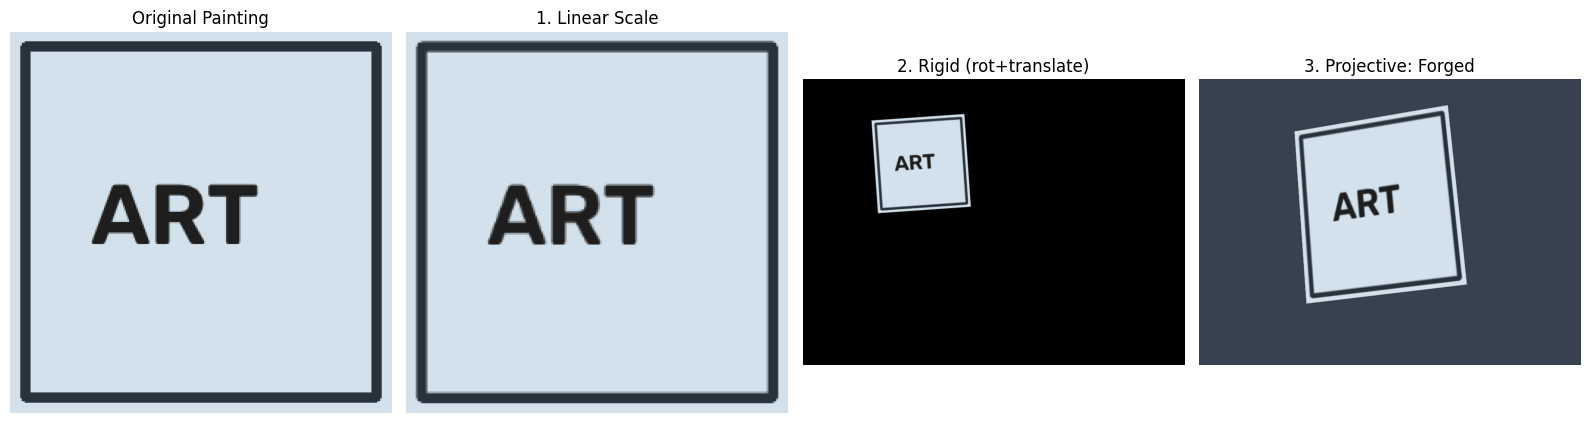

In [13]:
# Task 10: The Master Forger (Full Hierarchy Challenge)

# A flat "painting" to be forged into the frame
painting = np.full((260, 260, 3), (235, 225, 210), dtype=np.uint8)
cv2.rectangle(painting, (10, 10), (249, 249), (60, 50, 40), 6)
cv2.putText(painting, "ART", (55, 145), cv2.FONT_HERSHEY_SIMPLEX, 2, (30, 30, 30), 4)

wall = np.full((600, 800, 3), (80, 65, 55), dtype=np.uint8)  # blank museum wall

# --- Step 1: LINEAR SCALE - shrink the painting -------------------------
scale_factor = 0.75
Sc = np.float32([
    [scale_factor, 0, 0],
    [0, scale_factor, 0]
])
h0, w0 = painting.shape[:2]
scaled_painting = cv2.warpAffine(painting, Sc, (int(w0 * scale_factor), int(h0 * scale_factor)))

# --- Step 2: RIGID TRANSFORMATION - nudge it near the frame -------------
h1, w1 = scaled_painting.shape[:2]
angle2 = 4
Rg = cv2.getRotationMatrix2D((w1 // 2, h1 // 2), angle2, 1.0)  # scale=1.0 keeps it rigid
Rg[0, 2] += 150   # move toward the frame's rough position
Rg[1, 2] += 80
positioned = cv2.warpAffine(scaled_painting, Rg, (wall.shape[1], wall.shape[0]))

# --- Step 3: PROJECTIVE TRANSFORMATION - warp corners into the angled frame
src_corners = np.float32([[0, 0], [w1 - 1, 0], [w1 - 1, h1 - 1], [0, h1 - 1]])
frame_corners = np.float32([   # the 4 corners of the angled frame on the wall photo
    [200, 110],
    [520, 55],
    [560, 430],
    [225, 470]
])
H_forge = cv2.getPerspectiveTransform(src_corners, frame_corners)
forged = cv2.warpPerspective(scaled_painting, H_forge, (wall.shape[1], wall.shape[0]))

# Composite the forged painting onto the wall
mask = cv2.cvtColor(forged, cv2.COLOR_BGR2GRAY) > 0
result_wall = wall.copy()
result_wall[mask] = forged[mask]

print("Step 1 - Scale matrix:\n", Sc)
print("\nStep 2 - Rigid matrix:\n", Rg)
print("\nStep 3 - Projective (Homography) matrix:\n", H_forge)

plt.figure(figsize=(16, 5))
plt.subplot(1, 4, 1); plt.imshow(cv2.cvtColor(painting, cv2.COLOR_BGR2RGB)); plt.title("Original Painting"); plt.axis("off")
plt.subplot(1, 4, 2); plt.imshow(cv2.cvtColor(scaled_painting, cv2.COLOR_BGR2RGB)); plt.title("1. Linear Scale"); plt.axis("off")
plt.subplot(1, 4, 3); plt.imshow(cv2.cvtColor(positioned, cv2.COLOR_BGR2RGB)); plt.title("2. Rigid (rot+translate)"); plt.axis("off")
plt.subplot(1, 4, 4); plt.imshow(cv2.cvtColor(result_wall, cv2.COLOR_BGR2RGB)); plt.title("3. Projective: Forged"); plt.axis("off")
plt.tight_layout(); plt.show()
